# Initial Fuel Consumption and Mileage Analysis

In [1]:
%matplotlib inline

import sys
from pathlib import Path

# Add the src directory to the path so we can import the fuel_analysis package
sys.path.insert(0, str(Path("..") / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from fuel_analysis.loaders import load_fuel_data, load_odometer_data
from fuel_analysis.metrics import (
    fuel_records_to_dataframe,
    odometer_records_to_dataframe,
    total_fuel_volume,
    total_fuel_spending,
    average_fuel_price,
    fuel_type_summary,
    avg_price_by_country,
    avg_price_by_city,
    monthly_liters,
    monthly_spending,
    total_distance,
    monthly_km_driven,
    cumulative_distance,
    compute_consumption_estimates,
    consumption_estimates_to_dataframe,
)
from fuel_analysis.plotting import (
    plot_fuel_price_over_time,
    plot_monthly_liters,
    plot_monthly_spending,
    plot_monthly_km,
    plot_consumption_over_time,
    plot_avg_price_by_country,
    plot_avg_price_by_city,
)

## 1. Load and Validate Data

In [2]:
data_dir = Path("..") / "data"

fuel_records, fuel_validation = load_fuel_data(data_dir / "fuel_log.csv")
odometer_records, odometer_validation = load_odometer_data(data_dir / "odometer_log.csv")

print(f"Loaded {len(fuel_records)} fuel records")
print(f"Loaded {len(odometer_records)} odometer records")

Loaded 8 fuel records
Loaded 9 odometer records


### Validation Summaries

In [3]:
print("=== Fuel Data Validation ===")
print(fuel_validation.summary())
print()
print("=== Odometer Data Validation ===")
print(odometer_validation.summary())

=== Fuel Data Validation ===
Validation: 0 error(s), 0 warning(s)

=== Odometer Data Validation ===
Validation: 0 error(s), 0 warning(s)


### Convert to DataFrames

In [4]:
fuel_df = fuel_records_to_dataframe(fuel_records)
odometer_df = odometer_records_to_dataframe(odometer_records)

print("=== Fuel DataFrame Info ===")
print(f"Shape: {fuel_df.shape}")
print(f"Date range: {fuel_df['datetime'].min()} to {fuel_df['datetime'].max()}")
print()
fuel_df.info()
print()
fuel_df.head()

=== Fuel DataFrame Info ===
Shape: (8, 11)
Date range: 2024-03-15 08:30:00 to 2024-06-15 08:45:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   event_id             8 non-null      object        
 1   datetime             8 non-null      datetime64[ns]
 2   amount_eur           8 non-null      float64       
 3   liters               8 non-null      float64       
 4   price_per_liter_eur  8 non-null      float64       
 5   fuel_type            8 non-null      object        
 6   is_full_tank         8 non-null      object        
 7   station_name         8 non-null      object        
 8   city                 8 non-null      object        
 9   country              8 non-null      object        
 10  notes                8 non-null      object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usa

,event_id,datetime,amount_eur,liters,price_per_liter_eur,fuel_type,is_full_tank,station_name,city,country,notes
0,F001,2024-03-15 08:30:00,75.5,42.5,1.776,E10,true,Aral Tankstelle,Munich,DE,
1,F002,2024-03-28 17:45:00,82.3,45.2,1.821,E5,true,Shell Station,Innsbruck,AT,Highway stop
2,F003,2024-04-10 09:15:00,68.9,40.1,1.718,E10,false,Total Energies,Lyon,FR,Partial fill
3,F004,2024-04-22 14:00:00,71.2,41.8,1.703,E10,true,ENI Station,Bolzano,IT,
4,F005,2024-05-05 11:30:00,79.6,44.0,1.809,E5,unknown,OMV Tankstelle,Salzburg,AT,Full tank status unknown


In [5]:
print("=== Odometer DataFrame Info ===")
print(f"Shape: {odometer_df.shape}")
print(f"Date range: {odometer_df['datetime'].min()} to {odometer_df['datetime'].max()}")
print()
odometer_df.info()
print()
odometer_df.head()

=== Odometer DataFrame Info ===
Shape: (9, 4)
Date range: 2024-03-14 20:00:00 to 2024-06-20 19:00:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   event_id     9 non-null      object        
 1   datetime     9 non-null      datetime64[ns]
 2   odometer_km  9 non-null      float64       
 3   notes        9 non-null      object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 420.0+ bytes



,event_id,datetime,odometer_km,notes
0,O001,2024-03-14 20:00:00,45230.0,Before first fuel entry
1,O002,2024-03-22 18:00:00,45810.0,
2,O003,2024-04-05 09:00:00,46520.0,Before Lyon trip
3,O004,2024-04-18 12:00:00,47350.0,
4,O005,2024-05-01 08:00:00,48100.0,


## 2. Fuel-Only Metrics

In [6]:
print(f"Total fuel volume:   {total_fuel_volume(fuel_df):.2f} liters")
print(f"Total fuel spending: {total_fuel_spending(fuel_df):.2f} EUR")
print(f"Average fuel price:  {average_fuel_price(fuel_df):.4f} EUR/liter")

Total fuel volume:   341.50 liters
Total fuel spending: 603.80 EUR
Average fuel price:  1.7681 EUR/liter


In [7]:
print("=== Fuel Type Summary ===")
fuel_type_summary(fuel_df)

=== Fuel Type Summary ===


,fuel_type,count,total_liters,total_eur
0,E10,5,205.0,353.8
1,E5,3,136.5,250.0


In [8]:
print("=== Average Price by Country ===")
avg_price_by_country(fuel_df)

=== Average Price by Country ===


,country,avg_price_per_liter,total_liters
0,AT,1.815022,89.2
1,CH,1.862579,47.3
2,DE,1.752955,84.6
3,FR,1.718204,40.1
4,HR,1.698701,38.5
5,IT,1.703349,41.8


In [9]:
print("=== Average Price by City ===")
avg_price_by_city(fuel_df)

=== Average Price by City ===


,city,avg_price_per_liter,total_liters
0,Bolzano,1.703349,41.8
1,Innsbruck,1.820796,45.2
2,Lyon,1.718204,40.1
3,Munich,1.752955,84.6
4,Salzburg,1.809091,44.0
5,Split,1.698701,38.5
6,Zurich,1.862579,47.3


## 3. Odometer-Only Metrics

In [10]:
print(f"Total distance: {total_distance(odometer_df):.1f} km")
print()
print("=== Monthly Kilometers Driven ===")
monthly_km_driven(odometer_df)

Total distance: 5420.0 km

=== Monthly Kilometers Driven ===


,month,km_driven
0,2024-03-01,580.0
1,2024-04-01,830.0
2,2024-05-01,1400.0
3,2024-06-01,330.0


In [11]:
print("=== Cumulative Distance ===")
cumulative_distance(odometer_df)

=== Cumulative Distance ===


,datetime,cumulative_km
0,2024-03-14 20:00:00,0.0
1,2024-03-22 18:00:00,580.0
2,2024-04-05 09:00:00,1290.0
3,2024-04-18 12:00:00,2120.0
4,2024-05-01 08:00:00,2870.0
5,2024-05-15 10:30:00,3550.0
6,2024-05-30 17:00:00,4270.0
7,2024-06-14 09:00:00,5090.0
8,2024-06-20 19:00:00,5420.0


## 4. Combined Consumption Estimates

In [12]:
estimates = compute_consumption_estimates(fuel_records, odometer_records)
consumption_df = consumption_estimates_to_dataframe(estimates)

print(f"Computed {len(estimates)} consumption estimates")
print()
consumption_df

Computed 7 consumption estimates



,fuel_event_id,datetime,liters,estimated_km,liters_per_100km,liters_per_100km_quality,liters_per_100km_method,cost_per_100km,cost_per_100km_quality,cost_per_km,cost_per_km_quality,estimation_method,source_interval,amount_eur
0,F002,2024-03-28 17:45:00,45.2,853.959842,5.292989,estimated,linear,9.637456,estimated,0.096375,estimated,linear,F001 -> F002,82.3
1,F003,2024-04-10 09:15:00,40.1,714.731469,5.610499,estimated,linear,9.639984,estimated,0.096400,estimated,linear,F002 -> F003,68.9
2,F004,2024-04-22 14:00:00,41.8,751.787157,5.560084,estimated,linear,9.470766,estimated,0.094708,estimated,linear,F003 -> F004,71.2
3,F005,2024-05-05 11:30:00,44.0,711.245468,6.186331,estimated,linear,11.191635,estimated,0.111916,estimated,linear,F004 -> F005,79.6
4,F006,2024-05-18 16:20:00,38.5,633.024035,6.081918,estimated,linear,10.331361,estimated,0.103314,estimated,linear,F005 -> F006,65.4
5,F007,2024-06-01 10:00:00,47.3,662.605497,7.138486,estimated,linear,13.295996,estimated,0.132960,estimated,linear,F006 -> F007,88.1
6,F008,2024-06-15 08:45:00,42.1,775.381494,5.429585,estimated,linear,9.388927,estimated,0.093889,estimated,linear,F007 -> F008,72.8


## 5. Charts

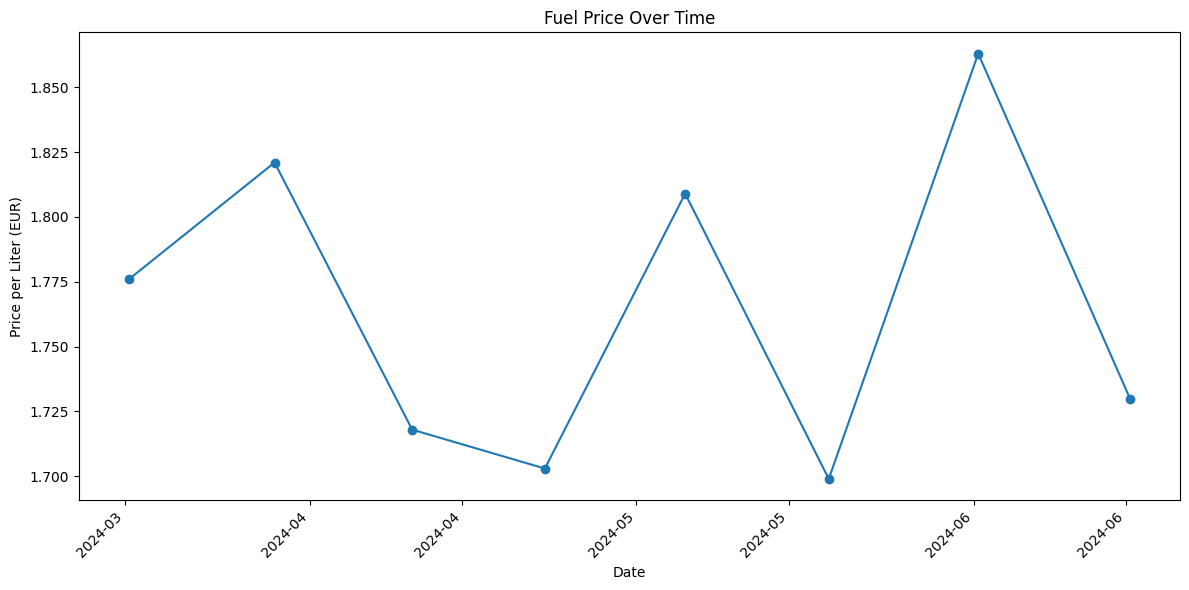

In [13]:
plot_fuel_price_over_time(fuel_df)
plt.show()

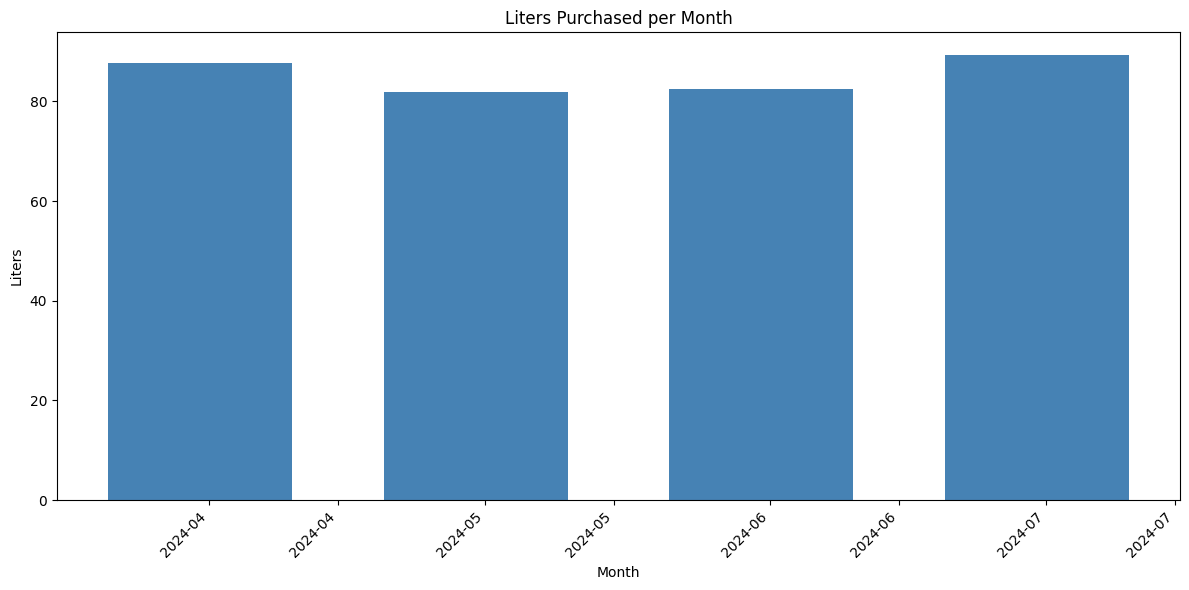

In [14]:
plot_monthly_liters(monthly_liters(fuel_df))
plt.show()

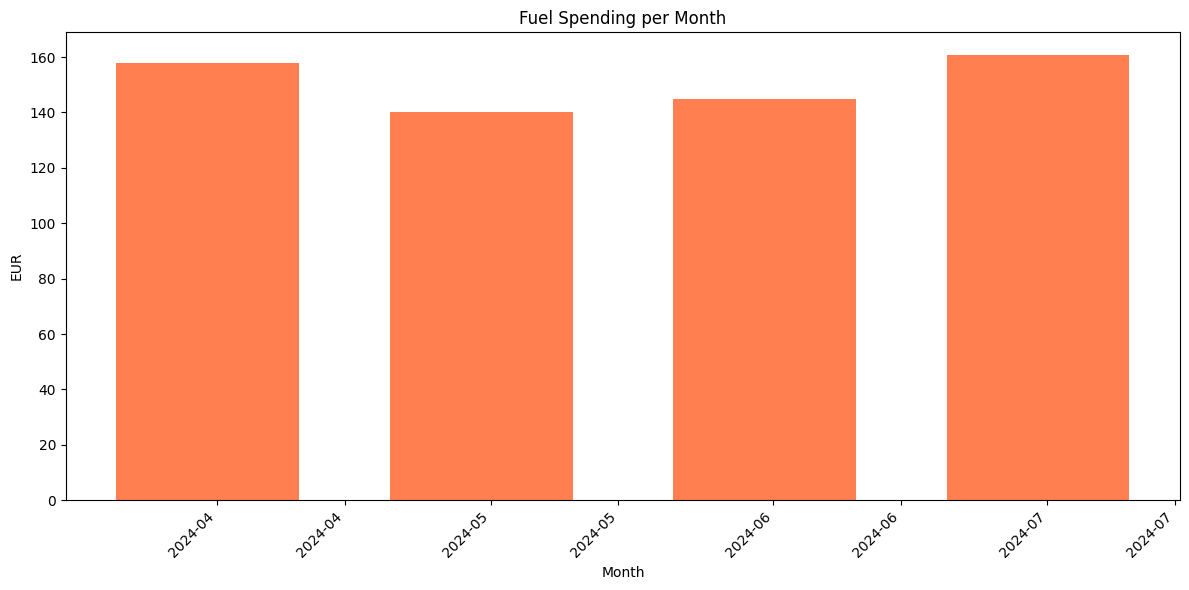

In [15]:
plot_monthly_spending(monthly_spending(fuel_df))
plt.show()

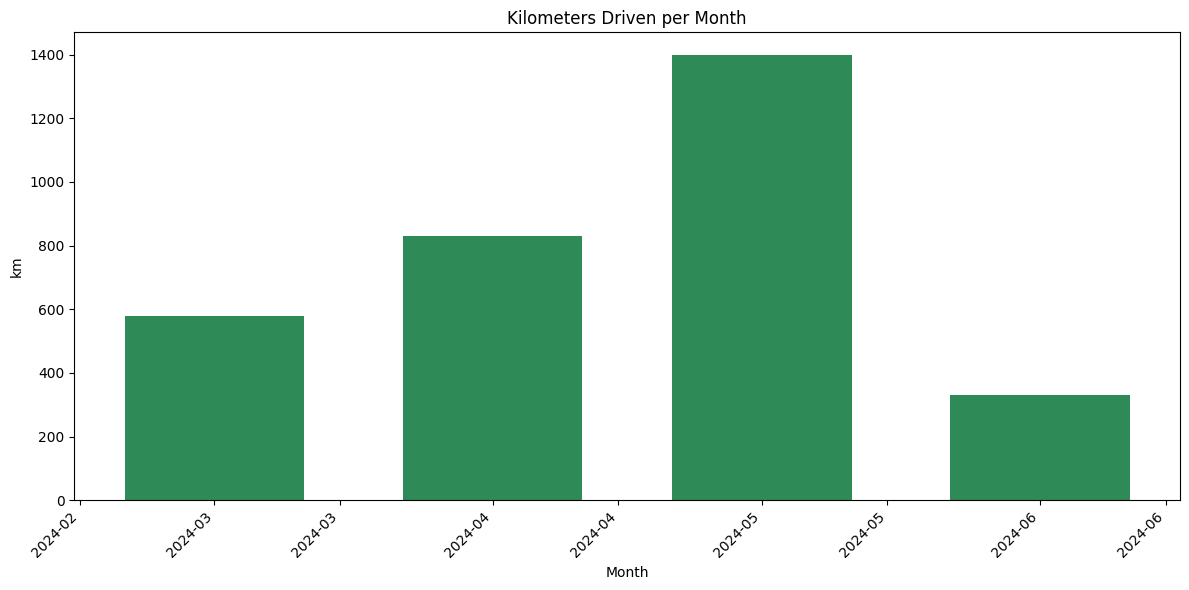

In [16]:
plot_monthly_km(monthly_km_driven(odometer_df))
plt.show()

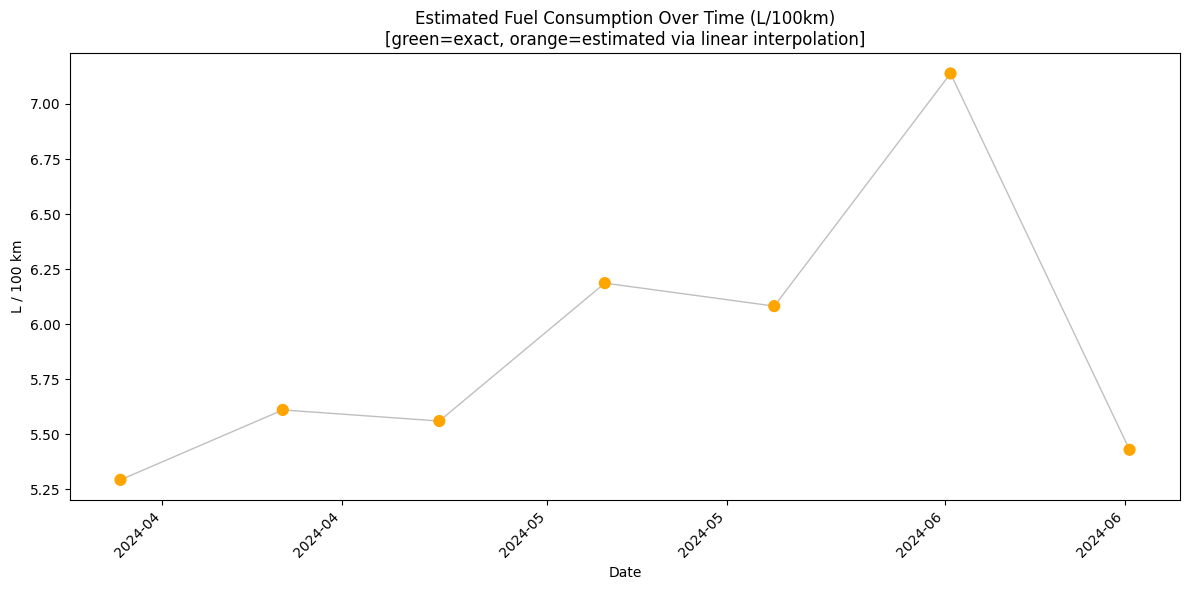

In [17]:
plot_consumption_over_time(consumption_df)
plt.show()

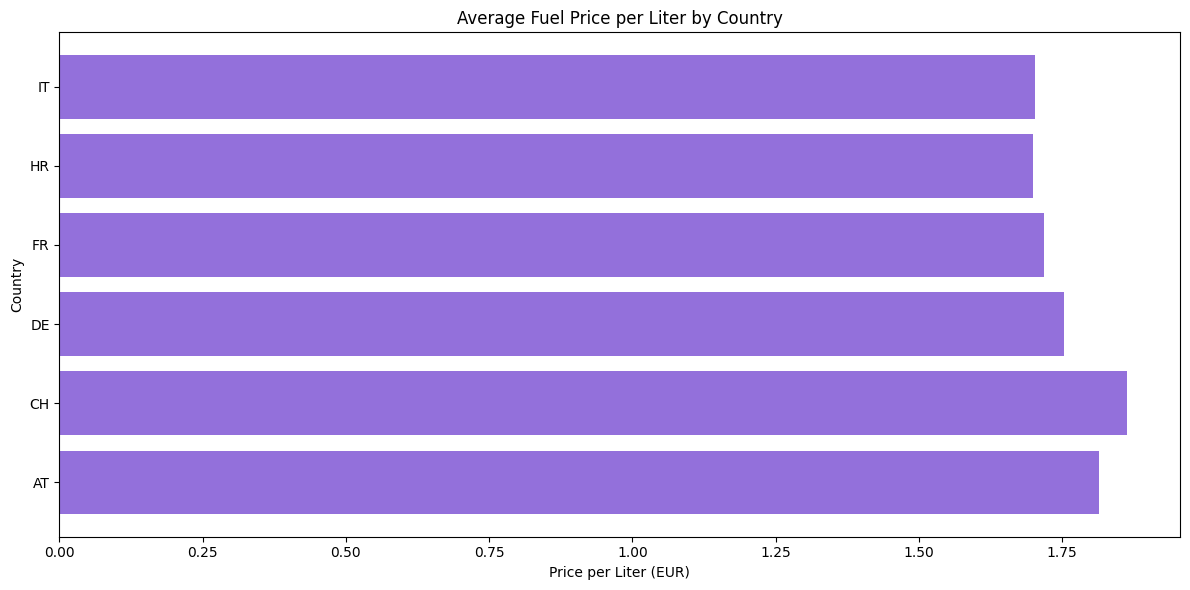

In [18]:
plot_avg_price_by_country(avg_price_by_country(fuel_df))
plt.show()

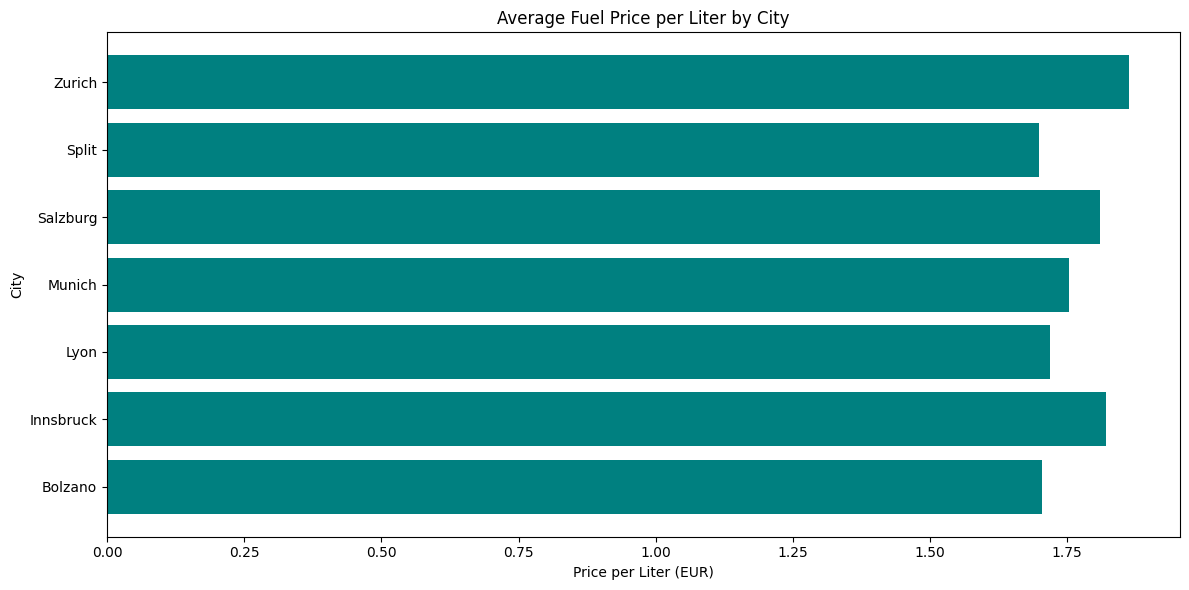

In [19]:
plot_avg_price_by_city(avg_price_by_city(fuel_df))
plt.show()

## Notes on Interpolation Methodology

**v1 uses linear interpolation** to estimate odometer readings at fuel event timestamps when no exact odometer reading exists at that time.

### Why linear interpolation?

Linear interpolation was chosen because it is the most conservative and interpretable approach for estimating odometer values between sparse, irregularly-spaced readings. It assumes constant driving speed between two known odometer observations, which is a reasonable first-order approximation.

### Why not higher-order methods?

Higher-order polynomial interpolation methods (e.g., Newton, Aitken-Neville, cubic splines) are **intentionally not used** in v1 for the following reasons:

- **Unnecessary for sparse real-world data**: Odometer readings are recorded at irregular, often widely-spaced intervals. Higher-order polynomials would impose structure that the data does not support.
- **Oscillatory artifacts (Runge phenomenon)**: Polynomial interpolation through sparse points can produce nonphysical oscillations, leading to nonsensical negative distances or implausible speed estimates.
- **Reduced interpretability**: Linear interpolation is trivial to audit and explain. Higher-order methods make it harder to trace how an estimated value was derived.
- **No justified model complexity**: Using a more complex model would imply knowledge about driving patterns that we do not have.

The architecture supports future extension to other interpolation strategies via the `InterpolationStrategy` protocol.

### Color coding in the consumption chart

In the consumption over time chart (L/100km), data points are color-coded by estimation quality:

- **Green**: Both odometer readings used to compute the interval were **exact** matches (an odometer reading existed at the exact fuel event timestamp).
- **Orange**: At least one of the two odometer readings was **estimated** via linear interpolation because no exact reading was available at the fuel event time.

This distinction makes it immediately visible which consumption values are based on measured data versus interpolated estimates.